In [ ]:
import string
import re
import numpy as np
import seaborn as sns
from tqdm import tqdm
from datasets import load_dataset
from huggingface_hub import hf_hub_download
from transformers import AutoTokenizer
import fasttext

ascii_uppercase = set(string.ascii_uppercase)

/home/ubuntu/asr-training/finetune-whisper/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
filename = hf_hub_download(
    repo_id="mesolitica/fasttext-language-detection-bahasa-en", 
    filename="fasttext.ftz"
)
lang_model = fasttext.load_model(filename)

In [3]:
def detect_lang(text):
    text = text.replace("\n", " ").replace("\r", " ").strip()
    
    labels, probs = lang_model.predict(text, k=10)
    clean_labels = [l.replace("__label__", "") for l in labels]
    
    if clean_labels[0] == "other" and len(clean_labels) > 1:
        return clean_labels[1]
    return clean_labels[0]

In [4]:
ds = load_dataset("Scicom-intl/emgs-recording-2025-10-13", "train")

In [5]:
ratio = []

for i in tqdm(range(len(ds['train']))):
    t = ds['train'][i]['text'].replace(' ', '')
    if len(t):
        upper = [c for c in t if c in ascii_uppercase]
        r = len(upper) / len(t)
    else:
        r = 0
    ratio.append(r)


100%|██████████| 3000/3000 [00:00<00:00, 19113.82it/s]


/tmp/ipykernel_5013/3015750314.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ratio)


<Axes: ylabel='Density'>

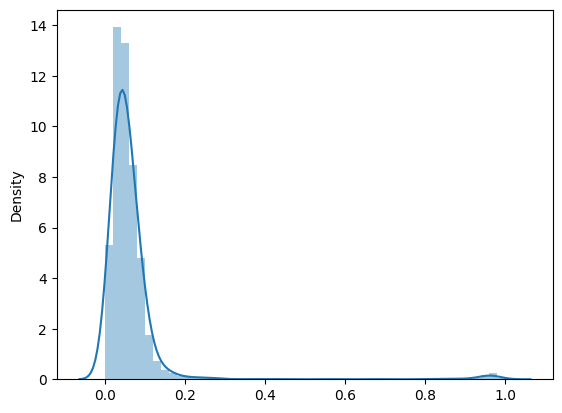

In [6]:
sns.distplot(ratio)

In [7]:
np_ratio = np.array(ratio)
np.where(np_ratio > 0.17)[0]

array([  11,   31,   35,   40,   50,   52,   53,   54,   55,   58,   64,
         76,  142,  190,  232,  302,  360,  372,  413,  511,  545,  842,
        850,  990, 1001, 1035, 1036, 1037, 1038, 1039, 1050, 1051, 1052,
       1053, 1054, 1055, 1056, 1057, 1058, 1059, 1061, 1068, 1105, 1351,
       1562, 1574, 1703, 1845, 2076, 2242, 2243, 2244, 2245, 2246, 2247,
       2248, 2249, 2250, 2251, 2252, 2253, 2254, 2255, 2256, 2257, 2346,
       2686, 2739, 2830, 2940])

In [8]:
for i in tqdm(range(len(ds['train']))):
    t = ds['train'][i]['text'].lower()
    if 'call end' in t:
        print(ds['train'][i]['text'])

100%|██████████| 3000/3000 [00:00<00:00, 27103.98it/s]

Hello? Can you provide me your telephone number? Of course. Sorry? Hello, my telephone number? Yes. umm wait. uhm, uhm is for trainer informational is ask from here right? CALL ENDS
Sekejap eh. Saya kena cari dalam dalam apa ni? Dalam WhatsApp je tau, Boleh boleh. E, E. CALL ENDS
SEC di Malaysian Malaysia Embassy di Malaysia. imi Malaysia. imi. Uhmm, Yeah, Malaysia. visaimi. co. imi. Itu mensyaratkan, photo. CALL ENDS
Application process. OK, before that can I get your details first can I have your name? Oh! my name is ADVAIP. OK, Can you provide me your telephone number sir?, 012, OK, 6076301. OK thank you for the information. yeah. Can you provide me your passport number sir? for me to check your record. Yes s05, S05, 66. CALL ENDS
Amari Anas Ali. "N". OK untuk untuk pelajaran apa yang saya boleh bantu? OK, application ini close conditional. Lepas itu pada 7May. kami ada buat, valcuration eh bukan apa cancelation buat cancelation. OK, tapi application ini tak proceed sebab kami. CALL

In [9]:
tokenizer = AutoTokenizer.from_pretrained('openai/whisper-large-v3-turbo')

In [10]:
input_str = '<|startoftranscript|><|ms|><|transcribe|><|notimestamps|> Hello<|endoftext|>'
tokenizer.tokenize(input_str), tokenizer(input_str, add_special_tokens=False)

(['<|startoftranscript|>',
  '<|ms|>',
  '<|transcribe|>',
  '<|notimestamps|>',
  'ĠHello',
  '<|endoftext|>'],
 {'input_ids': [50258, 50282, 50360, 50364, 2425, 50257], 'attention_mask': [1, 1, 1, 1, 1, 1]})

In [17]:
!rm -rf mosaic-stt

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


In [18]:
from streaming import MDSWriter, LocalDataset

columns = {
    'audio_filename': 'str',
    'text': 'str',
}
hashes = 'sha1', 'xxh64'
languages = ['en', 'ms']

with MDSWriter(out='mosaic-stt', columns=columns, compression=None, hashes=hashes) as out:
    for i in tqdm(range(len(ds['train']))):
        if ratio[i] >= 0.2:
            continue

        t = ds['train'][i]['text']
        if len(t):
            t = t.replace('CALL ENDS', '')
            t = re.sub(r'\s+', ' ', t).strip()
            lang = detect_lang(t)

            if lang == "bahasa":
                l = "ms"
            elif lang == "english":
                l = "en"
            else:
                l = "en"
            
            formatted_text = f'<|startoftranscript|><|{l}|><|transcribe|><|notimestamps|> {t}<|endoftext|>'
            d = {
                'text': formatted_text,
                'audio_filename': ds['train'][i]['audio_filename'],
            }
            out.write(d)

        else:
            for l in languages:
                formatted_text = f'<|startoftranscript|><|{l}|><|transcribe|><|notimestamps|> <|endoftext|>'
                d = {
                    'text': formatted_text,
                    'audio_filename': ds['train'][i]['audio_filename'],
                }
                out.write(d)

100%|██████████| 3000/3000 [00:00<00:00, 6963.87it/s]


In [19]:
dataset = LocalDataset('mosaic-stt')
len(dataset)

2973

In [23]:
dataset[0]

{'audio_filename': 'emgs-recording-audio/labelstudio-low-output_chunks-786001016867953_004.mp3',
 'text': '<|startoftranscript|><|ms|><|transcribe|><|notimestamps|> 2 8 1 6055, 2816055, Haah, OK, sebentar ya, OK, OK, cik tunggu ditalian sebentar, saya check dengan Ms Aisyah sekejap, ya. Oh, OK, OK, terima kasih,<|endoftext|>'}

In [22]:
from huggingface_hub import HfApi
api = HfApi()

api.upload_folder(
    folder_path="mosaic-stt",
    repo_id="Scicom-intl/mosaic-emgs-recording-2025-10-13",
    repo_type="dataset",
)

Processing Files (1 / 1): 100%|██████████| 1.56MB / 1.56MB,  0.00B/s  
New Data Upload: |          |  0.00B /  0.00B,  0.00B/s  
No files have been modified since last commit. Skipping to prevent empty commit.


CommitInfo(commit_url='https://huggingface.co/datasets/Scicom-intl/mosaic-emgs-recording-2025-10-13/commit/1d06cb0780204c8b6395d03ae1bd6634e074e13d', commit_message='Upload folder using huggingface_hub', commit_description='', oid='1d06cb0780204c8b6395d03ae1bd6634e074e13d', pr_url=None, repo_url=RepoUrl('https://huggingface.co/datasets/Scicom-intl/mosaic-emgs-recording-2025-10-13', endpoint='https://huggingface.co', repo_type='dataset', repo_id='Scicom-intl/mosaic-emgs-recording-2025-10-13'), pr_revision=None, pr_num=None)